# Parameter Selection Analysis

We need to make a guess of prior distribution for parameters. The closer it is to the true prior distribution, the better GNN model performance we will get. We can randomly select the parameter values and follow its distribution for ABC since we need to apply the information of our prior assumption.We don't want to do it for the GNN training since it is not our goal. In our GNN training, our goal is to make the performance better, and we are only selecting a few parameter values for training, so we want to avoid extreme cases, such as all randomly selected values are the same.

### Install

In [4]:
!pip install pyopencl

     -------------------------------------- 476.6/476.6 kB 2.7 MB/s eta 0:00:00
     ---------------------------------------- 96.0/96.0 kB 5.7 MB/s eta 0:00:00
     ---------------------------------------- 43.8/43.8 kB 2.1 MB/s eta 0:00:00
     ---------------------------------------- 79.9/79.9 kB 2.2 MB/s eta 0:00:00
  Attempting uninstall: typing_extensions
    Found existing installation: typing_extensions 4.4.0
    Uninstalling typing_extensions-4.4.0:
      Successfully uninstalled typing_extensions-4.4.0


In [6]:
!pip install PyOpenGL PyOpenGL_accelerate

     ---------------------------------------- 3.2/3.2 MB 4.7 MB/s eta 0:00:00
     -------------------------------------- 424.2/424.2 kB 4.4 MB/s eta 0:00:00


In [62]:
!pip install mako

     ---------------------------------------- 78.5/78.5 kB 4.6 MB/s eta 0:00:00


### 5000 samples

In [7]:
import numpy as np
import itertools
from scipy.stats import norm
import matplotlib.pyplot as plt
import sys
sys.path.append('C:/Users/MECHREV/CellModeller-ingallslab')  # change the path as needed
from CellModeller.Simulator import Simulator
from datetime import datetime
import os
import math

In [8]:
np.random.seed(123)

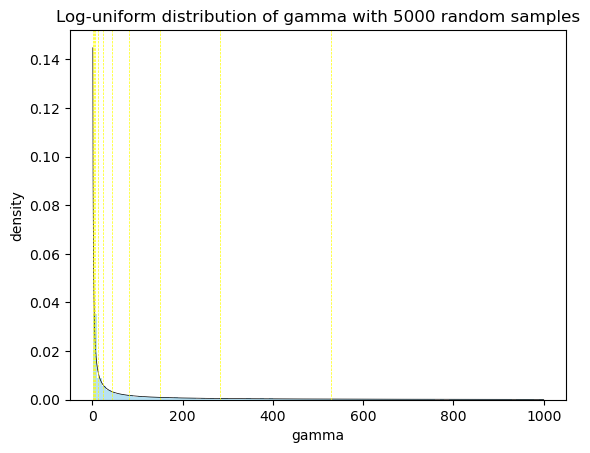

In [9]:
low = 0
high = 3  
size = 5000
num = 10
quantiles = np.linspace(0, 1, num+2)[1:-1]

power_samples = np.random.uniform(low=low, high=high, size=size)
samples = [10**s for s in power_samples]
x_cuts = [np.quantile(samples, q) for q in quantiles]

plt.hist(samples, bins=100, density=True, alpha=0.6, color='skyblue')

x = np.linspace(10**low, 10**high, 5000)
pdf = 1/(high*x*math.log(10))
plt.plot(x, pdf, 'k', linewidth=0.5)

for x in x_cuts:
    plt.axvline(x, color='yellow', linestyle='--', linewidth=0.5)

plt.title('Log-uniform distribution of gamma with 5000 random samples')
plt.xlabel('gamma')
plt.ylabel('density')
plt.show()

In [10]:
gamma_cuts = [round(x,5) for x in x_cuts]
gamma_cuts

[1.83134,
 3.32486,
 6.2484,
 11.89172,
 23.20622,
 43.52825,
 81.02885,
 148.96389,
 283.53498,
 528.18711]

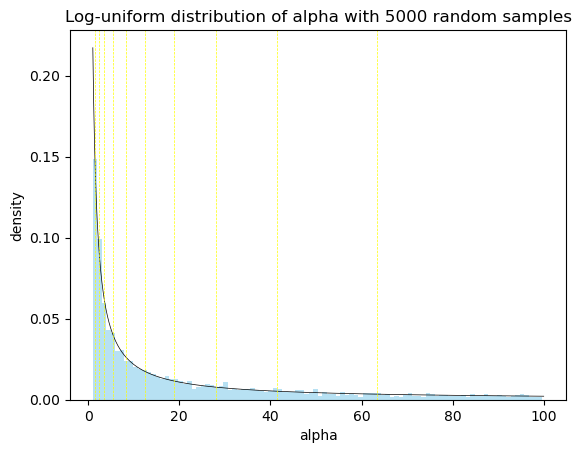

In [11]:
# alpha = reg_param
low = 0
high = 2  
size = 5000
num = 10
quantiles = np.linspace(0, 1, num+2)[1:-1]

power_samples = np.random.uniform(low=low, high=high, size=size)
samples = [10**s for s in power_samples]
x_cuts = [np.quantile(samples, q) for q in quantiles]

plt.hist(samples, bins=100, density=True, alpha=0.6, color='skyblue')

x = np.linspace(10**low, 10**high, 5000)
pdf = 1/(high*x*math.log(10))
plt.plot(x, pdf, 'k', linewidth=0.5)

for x in x_cuts:
    plt.axvline(x, color='yellow', linestyle='--', linewidth=0.5)

plt.title('Log-uniform distribution of alpha with 5000 random samples')
plt.xlabel('alpha')
plt.ylabel('density')
plt.show()

In [12]:
alpha_cuts = [round(x,5) for x in x_cuts]
alpha_cuts

[1.57594,
 2.2782,
 3.44735,
 5.33816,
 8.24628,
 12.53099,
 18.7817,
 28.14584,
 41.48342,
 63.45695]

### 1000 samples

We need to make a guess of prior distribution for parameters. The closer it is to the true prior distribution, the better GNN model performance we will get. We can randomly select the parameter values and follow its distribution for ABC since we need to apply the information of our prior assumption.We don't want to do it for the GNN training since it is not our goal. In our GNN training, our goal is to make the performance better, and we are only selecting a few parameter values for training, so we want to avoid extreme cases, such as all randomly selected values are the same.


In [15]:
import matplotlib.pyplot as plt
import numpy as np

def loguniform_by_random(low, high, size) -> list:
    power_samples = np.random.uniform(low=low, high=high, size=size)
    data = [10**s for s in power_samples]
    plt.hist(data, bins=1000, density=True, alpha=1, color='g')
    plt.xlabel("alpha")
    plt.ylabel("density")
    plt.title("Log-uniform distribution of alpha with 1000 random samples")
    plt.show()
    return data

gamma:


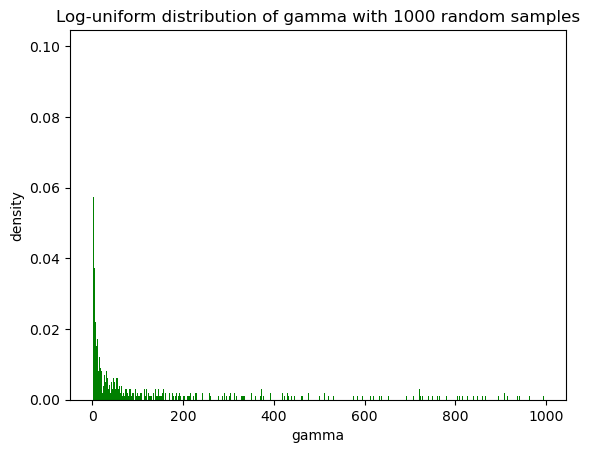

In [14]:
print("gamma:")
data = loguniform_by_random(0, 3, 1000)

alpha:


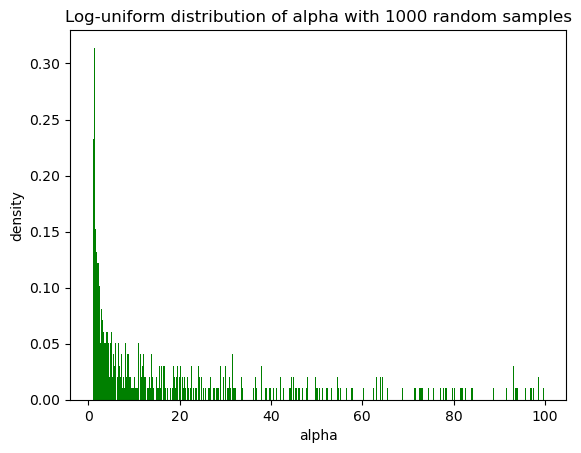

In [16]:
print("alpha:")
data = loguniform_by_random(0, 2, 1000)